In [1]:
import gdsfactory as gf
from gsim.palace import DrivenSim

gf.gpdk.PDK.activate()

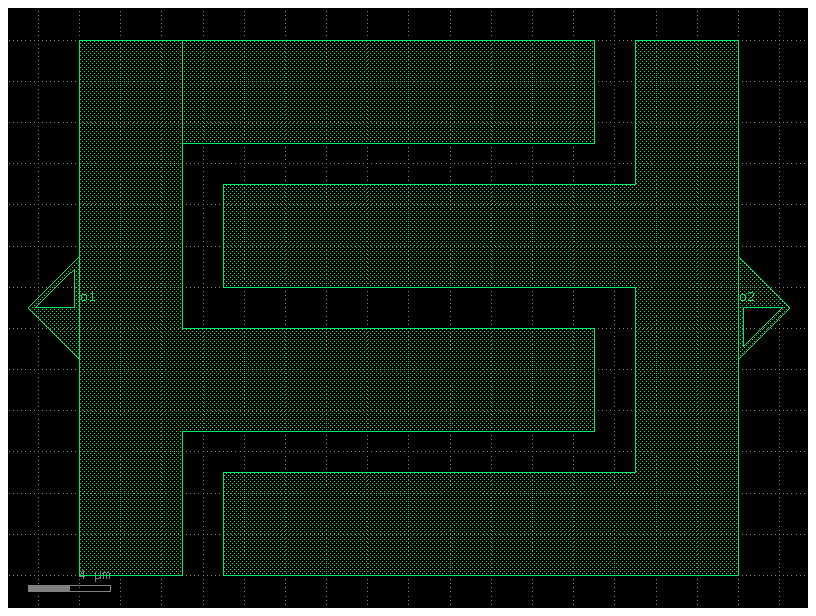

In [ ]:
c=gf.components.interdigital_capacitor(
    fingers=4,
    finger_length=20,
    finger_gap=2,
    thickness=5,
    layer='M1'
    )

# If we try meshing directly, without merging the polygons, we get this error in sim.mesh: 
# Error   : Could not create line
# Error   : Curve loop is not closed
cc = c.copy() 
cc.flatten()

c.draw_ports()
c.plot()

In [ ]:
# Checking the port layers.
cc.ports

["Port(self.name='o1', self.width=5000, trans=r180 *1 0,13, layer=M1 (41/0), port_type=optical)", "Port(self.name='o2', self.width=5000, trans=r0 *1 32,13, layer=M1 (41/0), port_type=optical)"]

In [4]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-idc")
sim.set_geometry(cc)

sim.set_stack(
    substrate_thickness=2.0,
    air_above=5.0,
)

sim.add_port(name="o1", layer="metal1",geometry="inplane", excited=True)
sim.add_port(name="o2", layer="metal1", geometry="inplane", excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [ ]:
# If there is an error, restart the kernel and run all cells again.

sim.mesh(preset="graded",margin=5.0,refined_mesh_size=0.3)

Mesh Summary
Dimensions: 42.0 x 36.0 x 12.6 µm
Nodes:      9,244
Elements:   67,581
Tetrahedra: 52,437
Edge length: 0.18 - 11.91 µm
Quality:    0.617 (min: 0.037)
SICN:       0.666 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (9):
  - metal1_xy [4]
  - metal1_z [5]
  - P1 [6]
  - P2 [7]
  - SiO2__None [8]
  - SiO2__passive [9]
  - passive__None [10]
  - air__passive [11]
  - air__None [12]
----------------------------------------
Mesh:   runs/palace-sim-idc/palace.msh

2026-03-17 16:47:33.889 (   2.304s) [    732D3CD1A080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:47:33.900 (   2.315s) [    732D3CD1A080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:47:33.915 (   2.330s) [    732D3CD1A080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

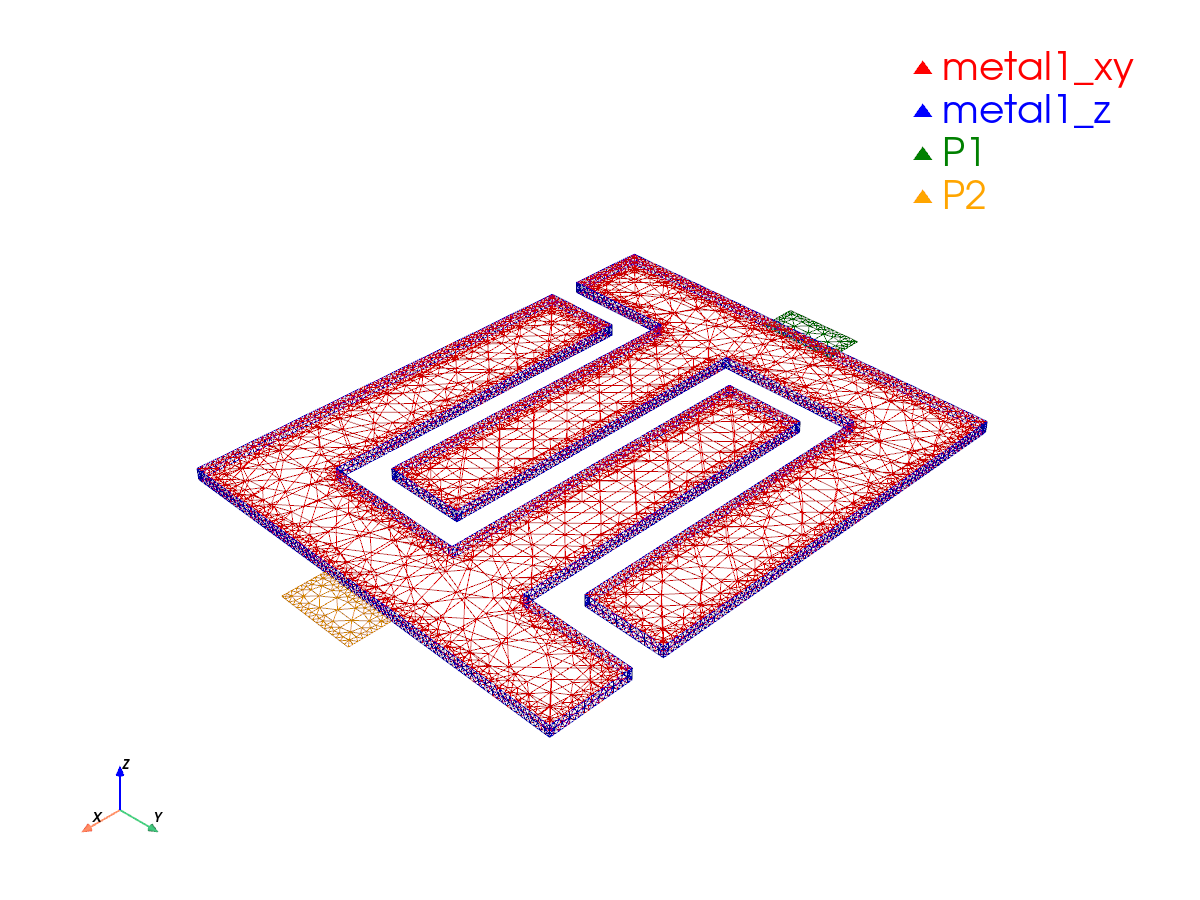

In [6]:
sim.plot_mesh(show_groups=["metal", "P"], interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:47:34.336 (   2.751s) [    732D3CD1A080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:47:34.345 (   2.760s) [    732D3CD1A080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:47:34.377 (   2.792s) [    732D3CD1A080]vt

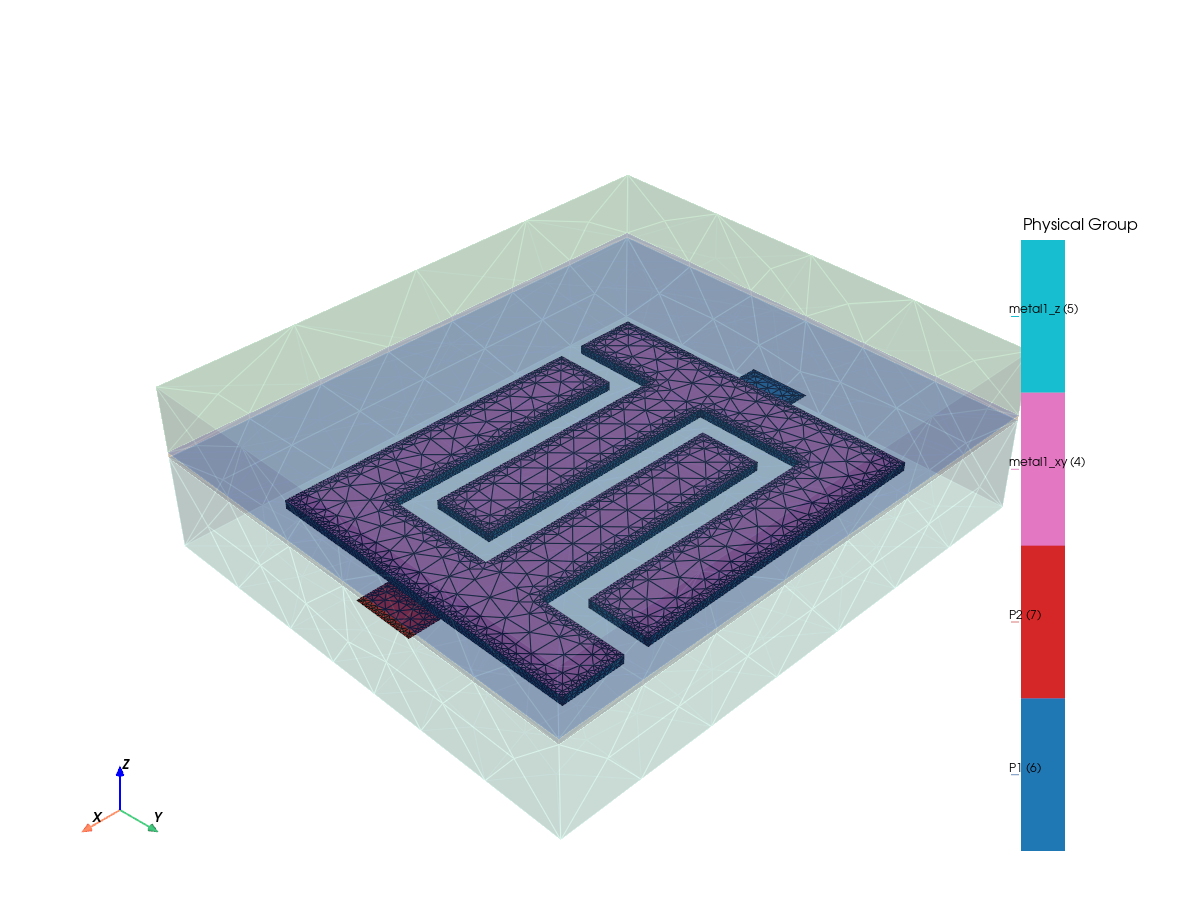

In [7]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["passive__None","air__None","air__passive","SiO2__None","SiO2__passive"],
)

In [8]:
results = sim.run(parent_dir="runs")

  palace-677b11a5  completed  0m 58s
Extracting results.tar.gz...
Downloaded 6 files to runs/sim-data-palace-677b11a5


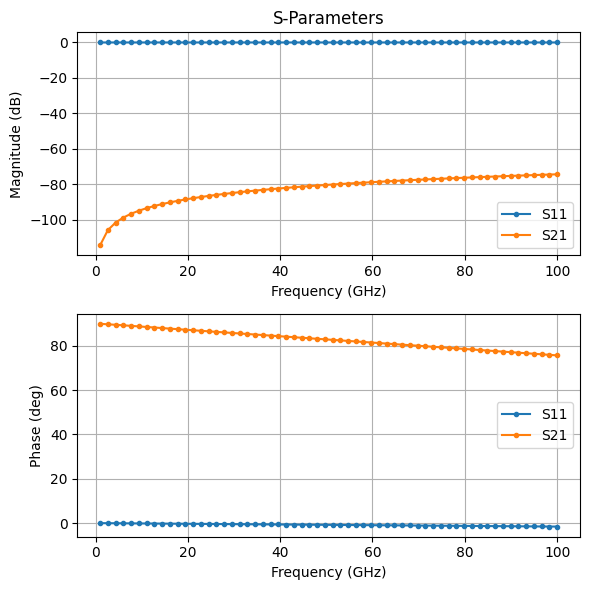

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()